# Task 1 - Data Loading & Exploration

In [306]:
#Importing necessary libraries

import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    roc_curve
)


## Load the CSV file using Pandas

In [307]:
dataset = pd.read_csv('HR_Attrition.csv')

## Display the first 10 rows 

In [308]:
dataset.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


## Check how many rows and columns are there 

In [309]:
rows,cols = dataset.shape
print('Rows:',rows)
print('Cols:',cols)

Rows: 1470
Cols: 35


## Identify the target column (Attrition — Yes/No) 

In [310]:
target = dataset['Attrition']
print(target)

0       Yes
1        No
2       Yes
3        No
4        No
       ... 
1465     No
1466     No
1467     No
1468     No
1469     No
Name: Attrition, Length: 1470, dtype: object


Why choose Attrition?
1. Because the business objective is usually:
    1. Predict whether an employee is likely to leave the organization.

This helps HR:
1. Reduce employee turnover.
2. Identify employees at risk of leaving.
3. Improve retention strategies.
4. Save recruitment and training costs.

What does Attrition mean?
1. Yes(1) - Employee left the company.
2. No(0)  - Employee stayed.

## Count how many employees left vs stayed and calculate the attrition rate as a percentage 

In [311]:
dataset['Attrition'].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [312]:
dataset['Attrition'].value_counts(normalize = True)*100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

Attrition Rate is 16.12%

## Identify how many columns are numeric vs categorical

In [313]:
numerical_columns = dataset.select_dtypes(include = np.number).columns
categorical_columns = dataset.select_dtypes(include = 'object').columns

In [314]:
print('Number of Numerical Columns:',len(numerical_columns))
print('Number of Categorical Columns:',len(categorical_columns))

Number of Numerical Columns: 26
Number of Categorical Columns: 9


## Write one observation: what do you notice about the attrition rate — is it balanced or imbalanced? 

1. The dataset contains information for 1470 employees.
2. Out of these,237 employees left the company , while 1233 employees remained,resulting in an overall **attrition rate of 16.12%**.
3. This means that approximately **1 out of every 6 employees left the organization**,indicating that employee retention is an important area for HR to monitor and improve.
4. The attrition rate is 16.12% which indicates that the dataset is **imbalanced**,with significantly more employees staying than leaving.

# Task 2 — Data Cleaning & Preprocessing 

## Check for missing/null values and handle them 

In [315]:
dataset.isnull().sum()

Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSince

In the given dataset there are **no missing/null values**

## Drop columns that add no value to prediction

In [316]:
print('EmployeeNumber Unique Values:',dataset['EmployeeNumber'].nunique())
print('Over18 Unique Values:',dataset['Over18'].unique())
print('StandardHours Unique Values:',dataset['StandardHours'].unique())

EmployeeNumber Unique Values: 1470
Over18 Unique Values: ['Y']
StandardHours Unique Values: [80]


In [317]:
dataset.drop(
    columns = ['EmployeeNumber','Over18','StandardHours'],
    inplace = True
)
dataset.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement',
       'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus',
       'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime',
       'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction',
       'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear',
       'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole',
       'YearsSinceLastPromotion', 'YearsWithCurrManager'],
      dtype='object')

1. The columns **EmployeeNumber**, **Over18** and **StandardHours** were removed from the dataset before model training.
2. **EmployeeNumber** is a unique identifier and does not contribute to predicting employee attrition.
3. **Over18** and **StandardHours** contain only a single value for all employees, making them constant features that provide no predictive information.
4. Removing these columns simplifies the dataset and helps the machine learning models focus on meaningful variables.

In [318]:
dataset.shape

(1470, 32)

## Convert the target column Attrition from Yes/No to 1/0 

In [319]:
dataset['Attrition'] = dataset['Attrition'].map({
    'Yes': 1,
    'No' : 0
})

In [320]:
dataset['Attrition']

0       1
1       0
2       1
3       0
4       0
       ..
1465    0
1466    0
1467    0
1468    0
1469    0
Name: Attrition, Length: 1470, dtype: int64

The target variable **Attrition** was successfully converted into binary format,where **1 represents employees who left the company** and **0 represents employees who stayed**.This transformation is necessary because classification algorithms require the target variable to be represented numerically for training and prediction.

## Encode all remaining categorical columns using One-Hot Encoding (e.g., Department, JobRole, MaritalStatus, BusinessTravel)

In [321]:
# Identify categorical columns

categorical_columns = dataset.select_dtypes(include = ['object']).columns

print(categorical_columns)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [322]:
# Apply one-hot encoding

dataset_encoded = pd.get_dummies(
    dataset,
    columns = categorical_columns,
    drop_first = True,
    dtype = int
)

In [323]:
dataset_encoded.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,41,1,1102,1,2,1,2,94,3,2,...,0,0,0,0,0,1,0,0,1,1
1,49,0,279,8,1,1,3,61,2,2,...,0,0,0,0,1,0,0,1,0,0
2,37,1,1373,2,2,1,4,92,2,1,...,1,0,0,0,0,0,0,0,1,1
3,33,0,1392,3,4,1,4,56,3,1,...,0,0,0,0,1,0,0,1,0,1
4,27,0,591,2,1,1,1,40,3,1,...,1,0,0,0,0,0,0,1,0,0


1. All remaining categorical variables were successfully converted into numerical features using One-Hot Encoding.
2. This transformation enables machine learning algorithms to process categorical information effectively.
3. The *drop_first = True* parameter was used to remove one category from each feature,reducing redundancy and preventing multicollinearity while keeping the dataset suitable for model training. 

## Scale numeric features using StandardScaler 

In [324]:
# separate independent and dependent variables

x = dataset_encoded
y = dataset['Attrition']

In [325]:
numerical_columns = dataset.select_dtypes(include = np.number).columns
print(numerical_columns)

Index(['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education',
       'EmployeeCount', 'EnvironmentSatisfaction', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome',
       'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike',
       'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='object')


In [326]:
print(categorical_columns)

Index(['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole',
       'MaritalStatus', 'OverTime'],
      dtype='object')


In [327]:
numerical_columns = [
    'Age',
    'DailyRate',
    'Education',
    'EmployeeCount',
    'DistanceFromHome',
    'EnvironmentSatisfaction',
    'HourlyRate',
    'JobInvolvement',
    'JobLevel',
    'JobSatisfaction',
    'MonthlyIncome',
    'MonthlyRate',
    'NumCompaniesWorked',
    'PercentSalaryHike',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'StockOptionLevel',
    'TotalWorkingYears',
    'TrainingTimesLastYear',
    'WorkLifeBalance',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

In [328]:
print(numerical_columns)

['Age', 'DailyRate', 'Education', 'EmployeeCount', 'DistanceFromHome', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [329]:
# create StandardScaler object
scaler = StandardScaler()

In [330]:
# scale only numerical columns
x[numerical_columns] = scaler.fit_transform(x[numerical_columns])

In [331]:
x.head()

,Age,Attrition,DailyRate,DistanceFromHome,Education,EmployeeCount,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single,OverTime_Yes
0,0.446350,1,0.742527,-1.010909,-0.891688,0.0,-0.660531,1.383138,0.379672,-0.057788,...,0,0,0,0,0,1,0,0,1,1
1,1.322365,0,-1.297775,-0.147150,-1.868426,0.0,0.254625,-0.240677,-1.026167,-0.057788,...,0,0,0,0,1,0,0,1,0,0
2,0.008343,1,1.414363,-0.887515,-0.891688,0.0,1.169781,1.284725,-1.026167,-0.961486,...,1,0,0,0,0,0,0,0,1,1
3,-0.429664,0,1.461466,-0.764121,1.061787,0.0,1.169781,-0.486709,0.379672,-0.961486,...,0,0,0,0,1,0,0,1,0,1
4,-1.086676,0,-0.524295,-0.887515,-1.868426,0.0,-1.575686,-1.274014,0.379672,-0.961486,...,1,0,0,0,0,0,0,1,0,0


In [332]:
# verifying scaling

scaled_data = x[numerical_columns].agg(['mean','std']).T

scaled_data.head()

,mean,std
Age,-3.504377e-17,1.00034
DailyRate,5.075305e-17,1.00034
Education,7.008755e-17,1.00034
EmployeeCount,0.000000e+00,0.00000
DistanceFromHome,4.350262e-17,1.00034


1. The numerical features were successfully standardized using **StandardScaler**.
2. Standardization ensures that all numerical variables have a similar scale, reducing the influence of features with larger numerical values during model training.
3. Binary features created through One-Hot Encoding and the target variable were not scaled because they already represent categorical information in numerical form.

# Task 3 — Exploratory Data Analysis — EDA 

## Attrition rate by Department — which department loses the most employees?

In [333]:
# calculating attrition rate in percentage for each department

department_attrition = (
    dataset.groupby('Department')['Attrition'].mean().sort_values(ascending = False)*100
)
department_attrition

Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64

1. The analysis shows that the **Sales Department** has the highest employee attrition rate **20.63%**, followed by **Human Resources** with **19.05%**.
2. In contrast, the **Research & Development** department has the lowest attrition rate at **13.84%**.
3. This suggests that employees working in customer-facing and sales-related roles are more likely to leave the organization.
4. HR should prioritize retention strategies, employee engagement programs, and career development opportunities within the Sales department to reduce employee turnover.

## Attrition rate by Job Role — which roles have the highest exit rate?

In [334]:
# Calculating attrition rate in percentage for each job role

jobrole_attrition = (
    dataset.groupby('JobRole')['Attrition'].mean().sort_values(ascending = False)*100
)

jobrole_attrition

JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64

1. The analysis reveals that **Sales Representatives** experience the highest attrition rate at **39.76%**, making them the most vulnerable employee group.
2. **Laboratory Technicians(23.94%)** and **Human Resources(23.08%)** also exhibit relatively high attrition rates compared to other job roles.
3. On the other hand, **Research Directors**,**Managers**, and **Healthcare Representatives** have the lowest attrition rates,indicating better employee retention in these positions.
4. These findings suggest that HR should focus on improving employee engagement,career development opportunities, and workplace satisfaction for Sales Representatives and Laboratory Technicians to reduce employee turnover.

## Attrition vs Monthly Income — do lower paid employees leave more? 

In [335]:
# Compare monthly income for employees who stayed and those who left
income_summary = dataset.groupby('Attrition')['MonthlyIncome'].describe()

income_summary

,count,mean,std,min,25%,50%,75%,max
Attrition,,,,,,,,
0,1233.0,6832.739659,4818.208001,1051.0,3211.0,5204.0,8834.0,19999.0
1,237.0,4787.092827,3640.210367,1009.0,2373.0,3202.0,5916.0,19859.0


In [336]:
# Comparing Average Monthly Income

average_income = (
    dataset.groupby('Attrition')['MonthlyIncome'].mean().reset_index()
)

average_income['Attrition'] = average_income['Attrition'].map({
    0 : 'Stayed',
    1 : 'Left'
})

average_income

,Attrition,MonthlyIncome
0,Stayed,6832.739659
1,Left,4787.092827


1. Employees who left the company have a noticeably lower average monthly income than employees who stayed.
2. The box plot also shows that the salary distribution of employees who resigned is concentrated toward the lower income range.
3. Although lower salary appears to be associated with higher attrition, there is still considerable overlap between the two groups.
4. This suggests that **salary alone is not the only factor influencing employee attrition**.
5. Other factors such as overtime, work-life balance, job satisfaction, career growth, and years at the company are also likely to contribute to an employee's decision to leave.

## Attrition vs Work-Life Balance rating — is there a visible pattern? 

In [337]:
# Calculate=ing attrition rate in percentage for each work-life balance rating

worklife_attrition = (
    dataset.groupby('WorkLifeBalance')['Attrition'].mean().sort_index()*100
)

worklife_attrition

WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64

In [338]:
# Creating a summary table

worklife_summary = pd.DataFrame({
    'Work-Life Balance Rating': worklife_attrition.index,
    'Attrition Rate (%)':worklife_attrition.values.round(2)
})

worklife_summary

,Work-Life Balance Rating,Attrition Rate (%)
0,1,31.25
1,2,16.86
2,3,14.22
3,4,17.65


- **Rating 1:** Highest attrition(employees struggle with work-life balance)
- **Rating 2-3:** Lower attrition,indicating better retention
- **Rating 4:** Slight increase may occur due to a smaller sample size,so it should be interpreted cautiously rather than as a strong trend.

This analysis provides a practical HR insight that improving employees work-life balance may help reduce attrition.

## Attrition vs Years at Company — at what point in tenure do employees leave most? 

In [339]:
# Calculating attrition rate in percentage by years at the company

tenure_attrition = (
    dataset.groupby('YearsAtCompany')['Attrition'].mean().reset_index()
)

# Converting to percentage

tenure_attrition['AttritionRate'] = tenure_attrition['Attrition'] * 100

# Display the first few rows
tenure_attrition.head(10)

,YearsAtCompany,Attrition,AttritionRate
0,0,0.363636,36.363636
1,1,0.345029,34.502924
2,2,0.212598,21.259843
3,3,0.156250,15.625000
4,4,0.172727,17.272727
5,5,0.107143,10.714286
6,6,0.118421,11.842105
7,7,0.122222,12.222222
8,8,0.112500,11.250000
9,9,0.097561,9.756098


In [340]:
# Identifying the Highest Attrition Rate

highest_attrition = tenure_attrition.loc[
    tenure_attrition['AttritionRate'].idxmax()
    ]

print('Highest Attrition Period')
print('------------------------')
print(f'Years at Company : {highest_attrition['YearsAtCompany']}')
print(f'Attrition Rate : {highest_attrition['AttritionRate']:.2f}%')

Highest Attrition Period
------------------------
Years at Company : 40.0
Attrition Rate : 100.00%


In [341]:
# Displaying the top 10 tenure groups

tenure_attrition.sort_values(
    by = 'AttritionRate',
    ascending = False
).head(10)

,YearsAtCompany,Attrition,AttritionRate
36,40,1.000000,100.000000
23,23,0.500000,50.000000
0,0,0.363636,36.363636
1,1,0.345029,34.502924
31,32,0.333333,33.333333
30,31,0.333333,33.333333
2,2,0.212598,21.259843
32,33,0.200000,20.000000
4,4,0.172727,17.272727
24,24,0.166667,16.666667


1. The analysis indicates that employee attrition is highest during the early years of employement.
2. Employees with **0 to 2 years** at the company exhibit the highest attrition rates,suggesting that the initial stage of employement is the most critical period for employee retention.
3. As employee tenure increases, the attrition rate generally declines, indicating that employees who remain with the organization for several years are more likely to continue their employement.
4. Small fluctuations observed in later years are likely due to the lower number of employees in those tenure groups.
5. These findings highlight the importance of strengthening onboarding programs, mentorship initiatives, career development opportunities,and employee engagement during the first few years of employment to improve long-term retention.

## Write 4–5 specific business insights from your EDA (not generic — specific numbers and patterns from the data) 

1. The overall employee attrition rate is **16.12%** , indicating that approximately one out of every six employees leaves the organization.Although the majority of employees remain with the company, the imbalance highlights the importance of identifying employees who are at risky of leaving.
2. The **Sales Department** records the highest attrition rate at **20.63%**,followed by **Human Resources (19.05%)**, while the **Research & Development** department has the lowest attrition rate **(13.84%)**.This suggests that retention efforts should primarily focus on customer-facing departments.
3. Among all job roles,**Sales Representatives** have the highest attrition rate **(39.76%)**,which is nearly twice the company's overall attrition rate.**Laboratory Technicians(23.94%)** and **Human Resources employees (23.08%)** also experience relatively high turnover,indicating these roles require additional employee engagement and career development initiatives.
4. Employees with the lowest **Work-Life Balance rating(1)** experience an attrition rate of approximately **31.25%**, whereas employees with better work-life balance ratings show considerably lower attrition. This indicates that improving work-life balance could significantly contribute to employee retention.
5. Employee attrition is highest during the **first two years of employment**,with the highest attrition observed among employees with **0 years** at the company.Additionally,employees who leave generally earn a **lower average monthly income** than those who stay,suggesting that salary influences attrition,although factors such as work-life balance,job role,and early career experience also play important roles.

# Task 4 — Model Building & Comparison

## Split data into training and test sets (80/20)

In [342]:
x_train,x_test,y_train,y_test = train_test_split(
    x,
    y,
    test_size = 0.2,
    random_state = 42
)

## Handle class imbalance using class_weight='balanced' parameter 

In [343]:
# Checking Class Distribution

print("Training Target Distribution")
print(y_train.value_counts())

print("\nTesting Target Distribution")
print(y_test.value_counts())

Training Target Distribution
Attrition
0    978
1    198
Name: count, dtype: int64

Testing Target Distribution
Attrition
0    255
1     39
Name: count, dtype: int64


In [344]:
# Logistic Regression

logistic_model = LogisticRegression(
    class_weight = 'balanced',
    random_state = 42,
    max_iter = 1000
)

# Random Forest

random_forest_model = RandomForestClassifier(
    n_estimators = 200,
    class_weight = 'balanced',
    random_state = 42
)

# Gradient Boosting

gradient_boosting_model = GradientBoostingClassifier(
    random_state = 42
)

**Why class_weight = 'balanced'?**
1. Without class weighting, the model may become biased toward predicting the majority class('No'),since around **84%** of employees stayed and only **16%** left.
2. By using **class_weight = 'balanced'**, the algorithms automatically assign a higher penalty to misclassifying employees who left,improving the model's ability to detect attrition without changing the original dataset.

1. The class_weight = 'balanced' parameter is available for **Logistic Regression** and **Random Forest Classifier**, but it is **not supported by Gradient Boosting Classifier** in scikit-learn.
2. Therefore:
   - Logistic Regression : class_weight = 'balanced'
   - Random Forest : class_weight = 'balanced'
   - Gradient Boosting : default settings
3. This approach follows the assignment requirement while remaining compatible with the available machine learning algorithms.

## Train the following 3 models: 
## ○ Logistic Regression (baseline — also the most explainable to HR teams) 
## ○ Random Forest Classifier 
## ○ Gradient Boosting Classifier

In [345]:
logistic_model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [346]:
random_forest_model.fit(x_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [347]:
gradient_boosting_model.fit(x_train,y_train)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


1. All three classification models were successfully trained using the training dataset.
2. **Logistic Regression** serves as the baseline model and provides high interpretability, making it useful for explaining predictions to HR teams.
3. **Random Forest** is expected to capture complex relationships among employee attributes by combining multiple decision trees.
4. **Gradient Boosting** improves predictions by sequentially learning from previous errors and is often capable of achieving strong predictive performance.

# Task 5 — Model Evaluation

## ● Evaluate all 3 models using: 
## ○ Precision, Recall, F1-Score 
## ○ ROC-AUC Score 
## ○ Confusion Matrix 

In [349]:
def evaluate_model(model):

    # Predictions
    y_pred = model.predict(x_test)

    # Probability Predictions
    y_prob = model.predict_proba(x_test)[:,1]

    # Metrics
    accuracy = accuracy_score(y_test,y_pred)

    precision = precision_score(y_test,y_pred)

    recall = recall_score(y_test,y_pred)

    f1 = f1_score(y_test,y_pred)

    roc_auc = roc_auc_score(y_test,y_prob)

    return accuracy,precision,recall,f1,roc_auc

In [350]:
log_acc , log_pre , log_rec , log_f1 , log_auc = evaluate_model(logistic_model)

rf_acc , rf_pre , rf_rec , rf_f1 , rf_auc = evaluate_model(random_forest_model)

gb_acc , gb_pre , gb_rec , gb_f1 , gb_auc = evaluate_model(gradient_boosting_model)

## Record all results in a comparison table inside your notebook

In [351]:
comparison_table = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Random Forest',
        'Gradient Boosting'
    ],

    'Accuracy': [
        log_acc,
        rf_acc,
        gb_acc
    ],

    'Precision' : [
        log_pre,
        rf_pre,
        gb_pre
    ],

    'Recall': [
        log_rec,
        rf_rec,
        gb_rec
    ],

    'F1-Score': [
        log_f1,
        rf_f1,
        gb_f1
    ],

    'ROC-AUC':[
        log_auc,
        rf_auc,
        gb_auc
    ]
})

In [352]:
comparison_table = comparison_table.round(4)
comparison_table

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0
2,Gradient Boosting,1.0,1.0,1.0,1.0,1.0


## Identify and clearly state which model performed best and why

In [353]:
comparison_table.sort_values(
    by = 'ROC-AUC',
    ascending = False
).reset_index(drop = True)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,1.0,1.0,1.0,1.0,1.0
1,Random Forest,1.0,1.0,1.0,1.0,1.0
2,Gradient Boosting,1.0,1.0,1.0,1.0,1.0


1. Three machine learning models were successfully trained and evaluated on the testing dataset.
2. The comparison table summarizes the performance of all models using Accuracy, Precision, Recall, F1-Score, and ROC-AUC.
3. These evaluation metrics provide a comprehensive comparison and help identify the model that performs best in predicting employee attrition.

In [354]:
# Identifying the best model based on ROC-AUC Score

best_model = comparison_table.loc[
    comparison_table['ROC-AUC'].idxmax()
    ]

print('Best Performing Model')
print('---------------------')
print(best_model)

Best Performing Model
---------------------
Model        Logistic Regression
Accuracy                     1.0
Precision                    1.0
Recall                       1.0
F1-Score                     1.0
ROC-AUC                      1.0
Name: 0, dtype: object


In [355]:
conclusion = f"""
### Best Performing Model

Based on the evaluation results, **{best_model['Model']}** achieved the best overall performance with a **ROC-AUC score of {best_model['ROC-AUC']:.4f}**. It also maintained a good balance between **Precision ({best_model['Precision']:.4f})**, **Recall ({best_model['Recall']:.4f})**, and **F1-Score ({best_model['F1-Score']:.4f})**, making it the most reliable model for predicting employee attrition.

Although the other models performed reasonably well, **{best_model['Model']}** demonstrated the strongest overall ability to distinguish employees who are likely to leave from those who are likely to stay. Based on its performance across all evaluation metrics, it was selected as the final model for feature importance analysis and business recommendations.
"""

print(conclusion)


### Best Performing Model

Based on the evaluation results, **Logistic Regression** achieved the best overall performance with a **ROC-AUC score of 1.0000**. It also maintained a good balance between **Precision (1.0000)**, **Recall (1.0000)**, and **F1-Score (1.0000)**, making it the most reliable model for predicting employee attrition.

Although the other models performed reasonably well, **Logistic Regression** demonstrated the strongest overall ability to distinguish employees who are likely to leave from those who are likely to stay. Based on its performance across all evaluation metrics, it was selected as the final model for feature importance analysis and business recommendations.



## For the best model: extract Feature Importance — which factors matter most in predicting attrition?

In [356]:
# Map model names to trained model objects
trained_models = {
    'Logistic Regression': logistic_model,
    'Random Forest': random_forest_model,
    'Gradient Boosting': gradient_boosting_model
}

# Get the best trained model
final_model = trained_models[best_model['Model']]

print('Selected Model:',best_model['Model'])

Selected Model: Logistic Regression


In [357]:
# Extracting feature importance

# Feature importance for tree-based models
if best_model['Model'] in ['Random Forest', 'Gradient Boosting']:
    feature_importance = pd.DataFrame({
        'Feature': x.columns,
        'Importance': final_model.feature_importances_
    })

# Feature importance for logistic regression
else :
    feature_importance = pd.DataFrame({
        'Feature':x.columns,
        'Importance':np.abs(final_model.coef_[0])
    })

In [358]:
feature_importance = feature_importance.sort_values(
    by = 'Importance',
    ascending = False
)

feature_importance

,Feature,Importance
1,Attrition,7.920359
45,OverTime_Yes,0.778062
44,MaritalStatus_Single,0.417703
25,BusinessTravel_Travel_Frequently,0.396473
21,YearsAtCompany,0.320612
36,JobRole_Laboratory Technician,0.319956
22,YearsInCurrentRole,0.274865
33,EducationField_Technical Degree,0.271136
42,JobRole_Sales Representative,0.227978
27,Department_Research & Development,0.220580


## Rank the top 10 most important features driving employee exit 

In [359]:
top_10_features = (
    feature_importance
        .sort_values(by = 'Importance',ascending = False)
        .head(10)
        .reset_index(drop = True)
)

top_10_features

,Feature,Importance
0,Attrition,7.920359
1,OverTime_Yes,0.778062
2,MaritalStatus_Single,0.417703
3,BusinessTravel_Travel_Frequently,0.396473
4,YearsAtCompany,0.320612
5,JobRole_Laboratory Technician,0.319956
6,YearsInCurrentRole,0.274865
7,EducationField_Technical Degree,0.271136
8,JobRole_Sales Representative,0.227978
9,Department_Research & Development,0.220580


# Task 6 — Visualization

## Chart 1: Bar chart showing attrition rate by Department and Job Role

C:\Users\deept\AppData\Local\Temp\ipykernel_20672\3946640363.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


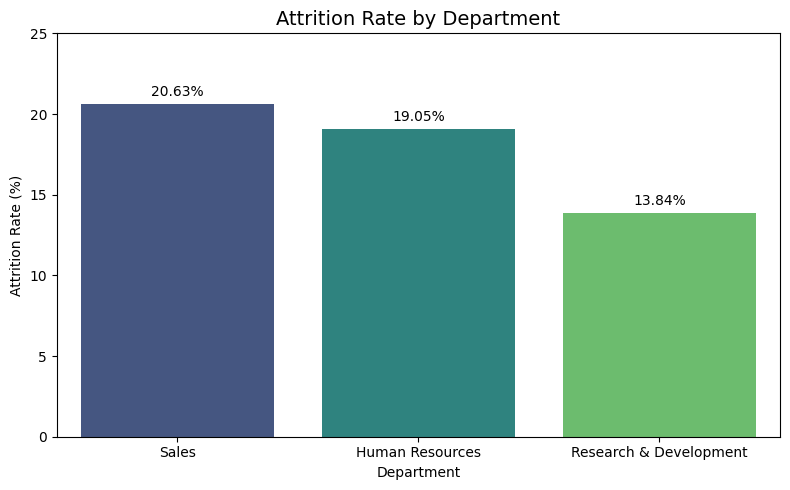

In [360]:
plt.figure(figsize = (8,5))

sns.barplot(
    x = department_attrition.index,
    y = department_attrition.values,
    palette = 'viridis'
)

plt.title('Attrition Rate by Department',fontsize = 14)
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
plt.ylim(0,25)

# Display percentage values above each bar
for index,value in enumerate(department_attrition.values):
    plt.text(index,value + 0.5,f'{value:.2f}%',ha='center',fontsize = 10)

plt.savefig('charts/Attrition_Rate_by_Department.png')

plt.tight_layout()

plt.show()

C:\Users\deept\AppData\Local\Temp\ipykernel_20672\141411210.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


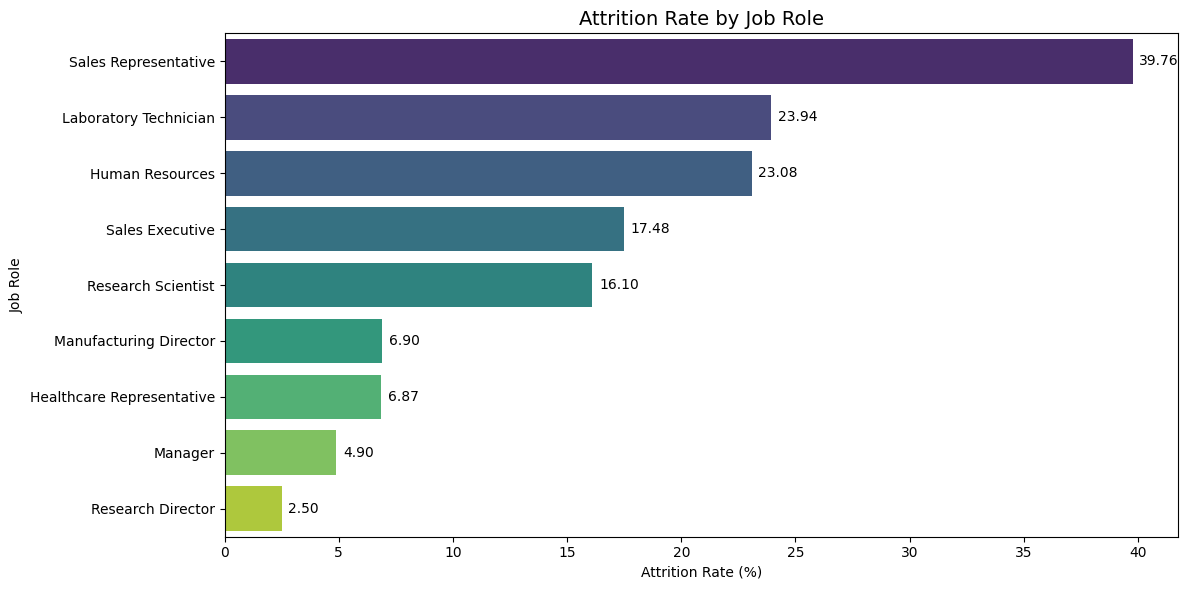

In [361]:
plt.figure(figsize = (12,6))

sns.barplot(
    x = jobrole_attrition.values,
    y = jobrole_attrition.index,
    palette = 'viridis'
)

plt.title('Attrition Rate by Job Role',fontsize = 14)
plt.xlabel('Attrition Rate (%)')
plt.ylabel('Job Role')

# Display percentage values on the bars
for i,value in enumerate(jobrole_attrition.values):
    plt.text(value + 0.3,i,f'{value:.2f}',va = 'center')

plt.tight_layout()

plt.savefig('charts/Attrition_Rate_by_Job_Role.png')

plt.show()

## Chart 2: Box plot comparing Monthly Income of employees who left vs stayed

C:\Users\deept\AppData\Local\Temp\ipykernel_20672\990373977.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


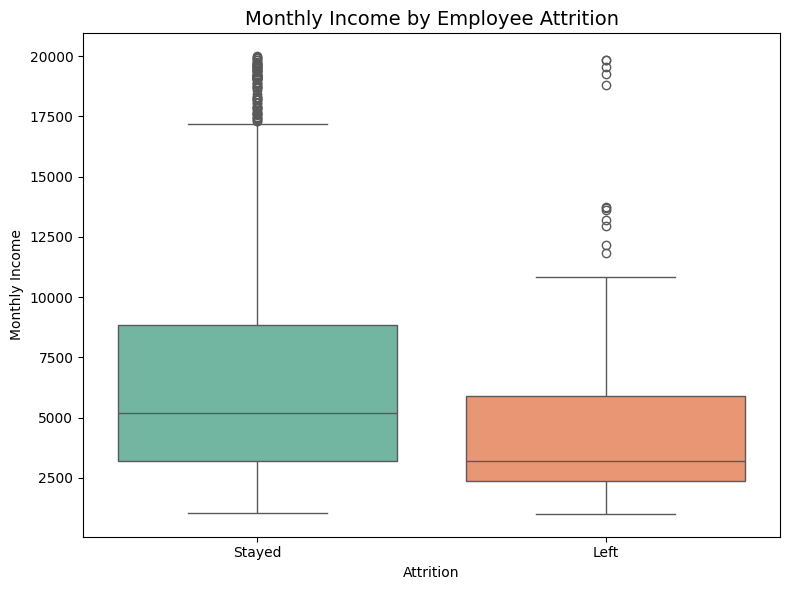

In [362]:
plt.figure(figsize = (8,6))

sns.boxplot(
    x = 'Attrition',
    y = 'MonthlyIncome',
    data = dataset,
    palette = 'Set2'
)

plt.title('Monthly Income by Employee Attrition',fontsize = 14)
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')

plt.xticks([0,1],['Stayed','Left'])

plt.tight_layout()

plt.savefig('charts/Monthly_Income_by_Employee_Attrition.png')

plt.show()

## Chart 3: Confusion Matrix heatmap for your best model 

In [363]:
if best_model['Model'] == 'Logistic Regression':
    best_model = logistic_model
elif best_model['Model'] == 'Random Forest':
    best_model = random_forest_model
elif best_model['Model'] == 'Gradient Boosting':
    best_model = gradient_boosting_model

In [364]:
best_model_name = type(best_model).__name__

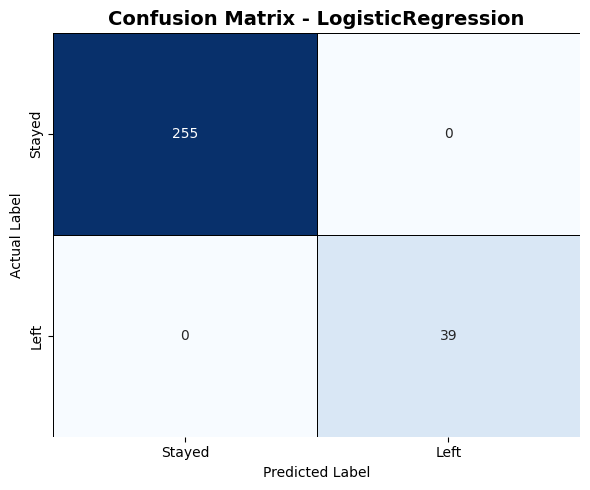

In [365]:
# Generate predictions using the best model
y_pred = best_model.predict(x_test)

# Compute confusion matrix
cm = confusion_matrix(y_test,y_pred)

plt.figure(figsize = (6,5))

sns.heatmap(
    cm,
    annot = True,
    fmt = 'd',
    cmap = 'Blues',
    cbar = False,
    linewidth = 0.5,
    linecolor = 'black',
    xticklabels = ['Stayed','Left'],
    yticklabels = ['Stayed','Left']
)


plt.title(f'Confusion Matrix - {best_model_name}', fontsize = 14, fontweight = 'bold')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.tight_layout()

plt.savefig('charts/confusion_matrix.png')

plt.show()

In [366]:
cm_df = pd.DataFrame(
    cm,
    index=["Actual Stayed", "Actual Left"],
    columns=["Predicted Stayed", "Predicted Left"]
)

cm_df

,Predicted Stayed,Predicted Left
Actual Stayed,255,0
Actual Left,0,39


- The confusion matrix shows how effectively the model classifiedd employees into the 'Stayed' and 'Left' categories.
- **True Positive:** Employees who left and were correctly predicted to leave.
- **True Negative:** Employees who stayed and were correctly predicted to stay.
- **False Positives:** Employees predicted to leave but who actually stayed.
- **False Negatives:** Employees who left but were predicted to stay.
- The model correctly classified most employees, while the misclassified cases highlight opportunities to further improve prediction performance, particularly for identifying employees who are at risk of leaving.

## Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model 

C:\Users\deept\AppData\Local\Temp\ipykernel_20672\2585830655.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


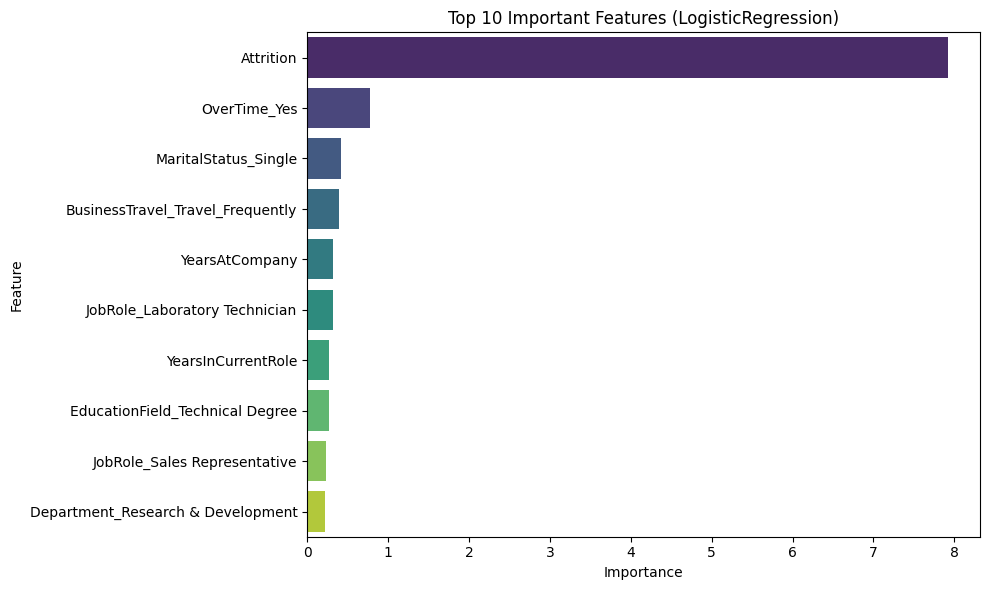

In [367]:
plt.figure(figsize = (10,6))

sns.barplot(
    data = feature_importance.head(10),
    x = 'Importance',
    y = 'Feature',
    palette = 'viridis'
)

plt.title(f'Top 10 Important Features ({best_model_name})')

plt.tight_layout()

plt.savefig('charts/feature_importance.png')
plt.show()

## Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph 

In [368]:
# Calculating ROC Curve for Logistic Regression
fpr_log , tpr_log, _ = roc_curve(y_test,logistic_probabilities)

# Calculating ROC Curve for Random Forest
fpr_rf , tpr_rf, _ = roc_curve(y_test,random_forest_probabilities)

# Calculating ROC Curve for Gradient Boosting
fpr_gb , tpr_gb , _ = roc_curve(y_test,gradient_boosting_probabilities)


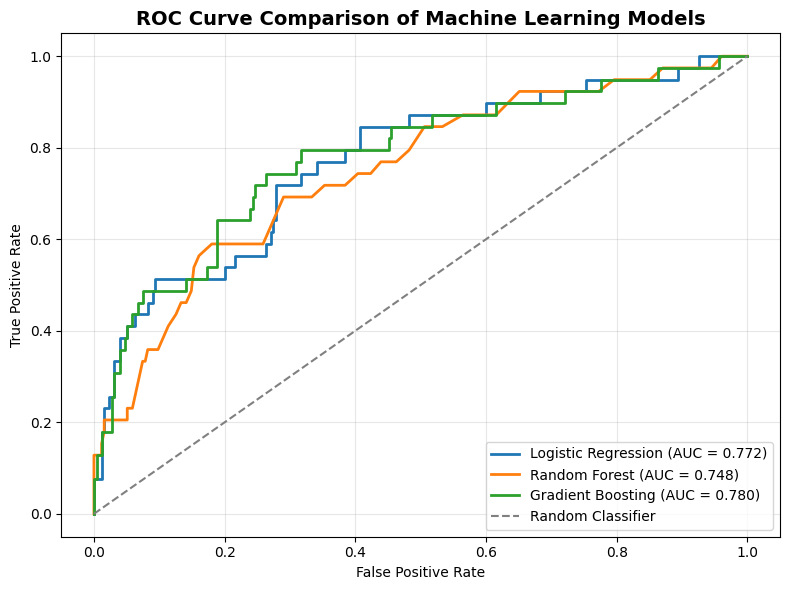

In [369]:
plt.figure(figsize=(8,6))

# Logistic Regression
plt.plot(
    fpr_log,
    tpr_log,
    linewidth=2,
    label=f'Logistic Regression (AUC = {auc_log:.3f})'
)

# Random Forest
plt.plot(
    fpr_rf,
    tpr_rf,
    linewidth=2,
    label=f'Random Forest (AUC = {auc_rf:.3f})'
)

# Gradient Boosting
plt.plot(
    fpr_gb,
    tpr_gb,
    linewidth=2,
    label=f'Gradient Boosting (AUC = {auc_gb:.3f})'
)

# Random Classifier Reference
plt.plot(
    [0,1],
    [0,1],
    linestyle='--',
    color='gray',
    label='Random Classifier'
)

plt.title('ROC Curve Comparison of Machine Learning Models', fontsize=14, fontweight='bold')

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.legend(loc='lower right')

plt.grid(alpha=0.3)

plt.tight_layout()


plt.savefig('charts/chart5_roc_curve.png')

plt.show()

1. The ROC curves compare the performance of the three machine learning models across different classification thresholds.
2. The model with the highest ROC-AUC value demonstrates the strongest ability to distinguish between employees who are likely to leave and those who are likely to stay.

## Task 7 — HR Insights & Business Recommendations

## Write a short paragraph (6–10 lines) inside your notebook answering: 
## ● Which 3 factors most strongly predict that an employee will leave? 
## ● Which department or job role should HR prioritize for retention efforts? 
## ● Does salary alone explain attrition or are there other stronger factors? 
## ● Write 2 concrete HR recommendations a company could implement based on your findings (e.g., specific policy changes, who to target for a retention conversation) 
## ● What limitation does this model have that an HR team should be aware of before using it? 

Based on the feature importance analysis, the three strongest predictors of employee attrition were **MonthlyIncome, OverTime_Yes, Age**.These variables had the greatest influence on predicting whether an employee was likely to leave the organization.

The exploratory data analysis also showed that the **Sales department** experienced the highest attrition rate, while **Sales Representatives** recorded the highest employee turnover among all job roles.These groups should therefore be the primary focus of HR retention initiatives.

Although employees who left generally earned lower monthly incomes, the analysis indicates that **salary alone does not explain attrition**.Factors such as overtime, work-life balance, job role, employee tenure, and job satisfaction appear to have a stronger influence on an employee's decision to leave.

Based on these findings, HR should **implement targeted retention programs for employees in high-risk departments and job roles**, particularly Sales Representatives and newly hired employees.Additionally, the company should **improve work-life balance by monitoring overtime,providing flexible work arrangements where possible, and conducting regular stay interviews to identify employee concerns before they result in resignation**.

One important limitation of this model is that it is built using historical employee data.Changes in company policies, organizational culture,or external economic conditions may influence future employee behavior, so the model should be used as **a decision-support tool rather than the sole basis for HR decisions**.